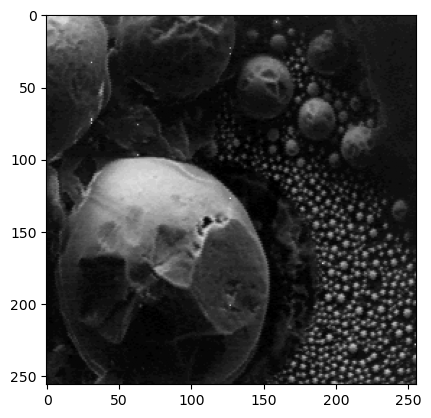

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

image = cv2.imread("images/MEB.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

In [4]:
#Cargue la imagen meb.png y remuestréela para obtener una imagen de tamaño 2048x2048.
imagen_r =  cv2.resize(image, (2048,2048), interpolation=cv2.INTER_NEAREST)

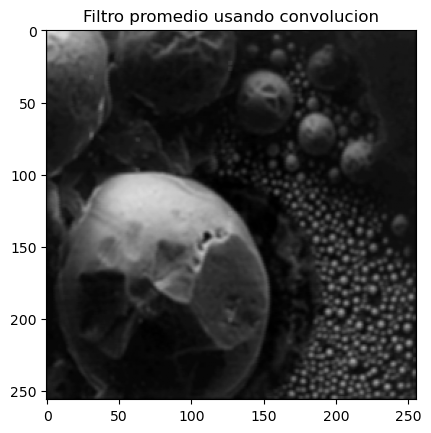

Tiempo total: 2.8588218688964844 segundos
Tiempo promedio por ejecución: 0.00028588218688964845 segundos


In [5]:
#Aplique un filtros promedio de 3x3 a la imagen usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.
from skimage.morphology import footprint_rectangle
from scipy.ndimage import convolve
from skimage.filters.rank import mean
import time

kernel = np.array([[1,1,1],
                   [1,1,1],
                   [1,1,1]], dtype=np.float32) / 9

num_iteraciones = 10000

start = time.time()

for i in range(num_iteraciones):
    res = convolve(image, kernel, mode='constant', cval=0)

end = time.time()

tiempo_total = end - start
tiempo_promedio = tiempo_total / num_iteraciones

#Imagen resultado
image_result1= convolve(image, kernel, mode='constant', cval=0)
plt.imshow(image_result1, cmap="gray",  vmin=0, vmax=255)
plt.title("Filtro promedio usando convolucion")
plt.show()

print("Tiempo total:", tiempo_total, "segundos")
print("Tiempo promedio por ejecución:", tiempo_promedio, "segundos")



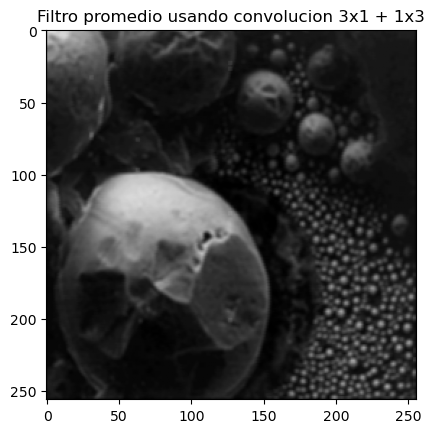

Tiempo total: 3.883686065673828 segundos
Tiempo promedio por ejecución: 0.0003883686065673828 segundos


In [10]:
#Aplique un filtro promedio de 3x1 sobre la imagen de trabajo y luego un filtro promedio de 1x3 usando una convolución. Realice varias ejecuciones y mida el tiempo de las mismas.

kernel_31 = np.array([[1],
                   [1],
                   [1]], dtype=np.float32) / 3

kernel_13 = np.array([[1,1,1]], dtype=np.float32) / 3

num_iteraciones = 10000

start = time.time()

for i in range(num_iteraciones):
    res = convolve(image, kernel_31, mode='constant', cval=0)
    res = convolve(res, kernel_13, mode='constant', cval=0)

end = time.time()

tiempo_total_separados = end - start
tiempo_promedio_separados = tiempo_total_separados / num_iteraciones


#Imagen resultado
res = convolve(image, kernel_31, mode='constant', cval=0)
image_result2 = convolve(res, kernel_13, mode='constant', cval=0)
plt.imshow(image_result2, cmap="gray",  vmin=0, vmax=255)
plt.title("Filtro promedio usando convolucion 3x1 + 1x3")
plt.show()

print("Tiempo total:", tiempo_total_separados, "segundos")
print("Tiempo promedio por ejecución:", tiempo_promedio_separados, "segundos")



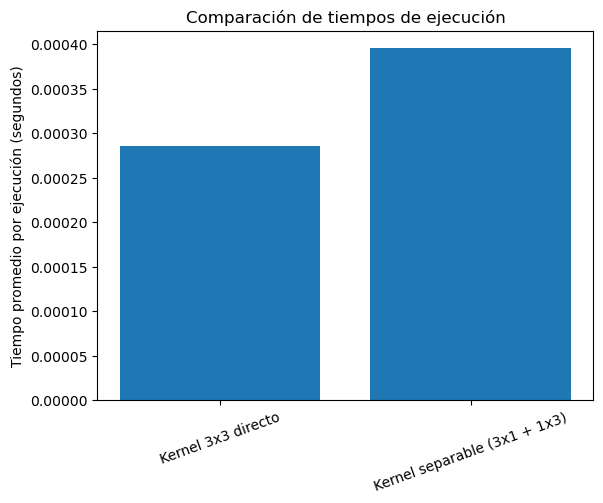

In [7]:
#Grafique el resultado comparativo de los tiempos de ejecución para los puntos anteriores.
import matplotlib.pyplot as plt

metodos = ["Kernel 3x3 directo", "Kernel separable (3x1 + 1x3)"]
tiempos = [tiempo_promedio, tiempo_promedio_separados]

plt.figure()
plt.bar(metodos, tiempos)

plt.ylabel("Tiempo promedio por ejecución (segundos)")
plt.title("Comparación de tiempos de ejecución")
plt.xticks(rotation=20)

plt.show()

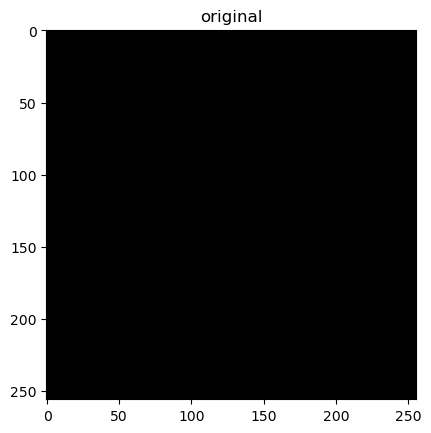

In [8]:
#Efectúe una sustracción de estas imágenes para corroborar el resultado Las dos imágenes resultantes, ¿son idénticas?
subtraction = cv2.subtract(image_result1, image_result2)

# Visualizar imagen
plt.imshow(subtraction, cmap="gray",  vmin=0, vmax=255)
plt.title("original")
plt.show()

Revise la siguiente explicación en separabilidad de filtros lineales. Explique la diferencia de los tiempos de ejecución determinando el número de operaciones elementales (SUMA, RESTA) efectuadas por las dos versiones del filtro. 

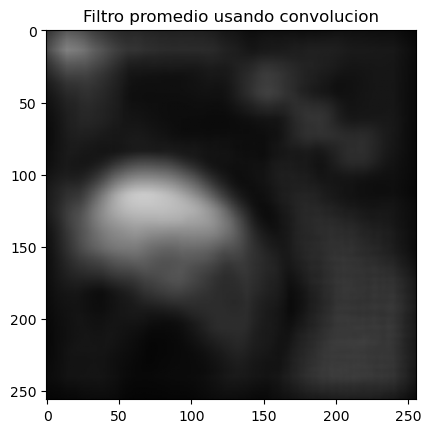

Tiempo total: 505.7868721485138 segundos
Tiempo promedio por ejecución: 0.05057868721485138 segundos


In [12]:
#Calcule la duración de ejecución que se debería obtener con un filtro promedio 10 veces más grande (es decir de tamaño 30x30).
# Verifique este resultado experimentalmente e intente explicar el tiempo de cálculo observado
# (pensando en los métodos de optimización utilizables con el filtro promedio separable).

from skimage.morphology import footprint_rectangle
from scipy.ndimage import convolve
from skimage.filters.rank import mean
import time

kernel_30 = np.ones((30, 30), dtype=np.float32) / (30 * 30)

num_iteraciones = 10000

start = time.time()

for i in range(num_iteraciones):
    res = convolve(image, kernel_30, mode='constant', cval=0)

end = time.time()

tiempo_total = end - start
tiempo_promedio = tiempo_total / num_iteraciones

#Imagen resultado
image_result1= convolve(image, kernel_30, mode='constant', cval=0)
plt.imshow(image_result1, cmap="gray",  vmin=0, vmax=255)
plt.title("Filtro promedio usando convolucion")
plt.show()

print("Tiempo total:", tiempo_total, "segundos")
print("Tiempo promedio por ejecución:", tiempo_promedio, "segundos")

